In [1]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
X_train = pd.read_csv('X_train_Iquitos.csv')
y_train = pd.read_csv('y_train_Iquitos.csv')
X_val = pd.read_csv('X_val_Iquitos.csv')
y_val = pd.read_csv('y_val_Iquitos.csv')

In [3]:
X_val

,cases_lag1,cases_lag2,cases_lag3,cases_lag4,cases_roll4,cases_roll8,T2M_lag1,T2M_MAX_lag1,T2M_MIN_lag1,PRECTOTCORR_lag1,...,WS2M_MIN_lag1,PRECTOTCORR_lag2,RH2M_lag2,T2M_lag2,PRECTOTCORR_lag3,RH2M_lag3,semana_sin,semana_cos,temp_rango_lag1,lluvia_hum_lag1
0,74.0,45.0,47.0,37.0,50.75,30.250,25.842857,28.834286,23.207143,6.124286,...,0.101429,0.591429,88.945714,26.344286,10.515714,92.805714,3.546049e-01,0.935016,5.627143,553.880400
1,95.0,74.0,45.0,47.0,65.25,41.250,25.878571,28.540000,23.452857,12.977143,...,0.054286,6.124286,90.440000,25.842857,0.591429,88.945714,4.647232e-01,0.885456,5.087143,1183.014882
2,86.0,95.0,74.0,45.0,75.00,51.500,26.392857,28.914286,24.138571,3.431429,...,0.021429,12.977143,91.161429,25.878571,6.124286,90.440000,5.680647e-01,0.822984,4.775714,310.554090
3,72.0,86.0,95.0,74.0,81.75,58.500,26.434286,28.828571,24.098571,2.542857,...,0.035714,3.431429,90.502857,26.392857,12.977143,91.161429,6.631227e-01,0.748511,4.730000,230.840571
4,65.0,72.0,86.0,95.0,79.50,65.125,26.325714,29.087143,23.858571,6.991429,...,0.052857,2.542857,90.780000,26.434286,3.431429,90.502857,7.485107e-01,0.663123,5.228571,638.247514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,16.0,24.0,17.0,21.0,19.50,16.125,26.450000,29.372857,23.968571,4.578571,...,0.024286,9.715714,90.104286,26.035714,8.997143,90.454286,-3.546049e-01,0.935016,5.404286,408.061908
256,24.0,16.0,24.0,17.0,20.25,17.750,26.384286,28.858571,24.418571,5.190000,...,0.035714,4.578571,89.124286,26.450000,9.715714,90.104286,-2.393157e-01,0.970942,4.440000,473.075914
257,40.0,24.0,16.0,24.0,26.00,21.375,26.257143,28.900000,23.981429,10.282857,...,0.028571,5.190000,91.151429,26.384286,4.578571,89.124286,-1.205367e-01,0.992709,4.918571,935.828139
258,20.0,40.0,24.0,16.0,25.00,21.750,25.940000,28.410000,23.897143,19.238571,...,0.032857,10.282857,91.008571,26.257143,5.190000,91.151429,6.432491e-16,1.000000,4.512857,1797.047473


In [4]:
X_val.columns

Index(['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4', 'cases_roll4',
       'cases_roll8', 'T2M_lag1', 'T2M_MAX_lag1', 'T2M_MIN_lag1',
       'PRECTOTCORR_lag1', 'RH2M_lag1', 'WS2M_lag1', 'WS2M_MAX_lag1',
       'WS2M_MIN_lag1', 'PRECTOTCORR_lag2', 'RH2M_lag2', 'T2M_lag2',
       'PRECTOTCORR_lag3', 'RH2M_lag3', 'semana_sin', 'semana_cos',
       'temp_rango_lag1', 'lluvia_hum_lag1'],
      dtype='object')

In [5]:
X_val = X_val.rename(columns = {
    'semana_sin': 'week_sin',
    'semana_cos': 'week_cos',
    'lluvia_hum_lag1': 'rain_hum_lag1'
})

In [6]:
y_val

,numero_de_casos
0,95
1,86
2,72
3,65
4,76
...,...
255,24
256,40
257,20
258,25


In [7]:
y_train

,numero_de_casos
0,7
1,2
2,5
3,13
4,14
...,...
1033,12
1034,37
1035,47
1036,45


In [8]:
model = joblib.load('modelo_lgbm_iquitos.pkl')
y_pred = model.predict(X_val)

r2 = r2_score(y_val, y_pred)

mse = mean_squared_error(y_val, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_val, y_pred)

def calculate_mase(y_val, predictions, y_train=None, seasonality=1):

    y_val = np.asarray(y_val)
    predictions = np.asarray(predictions)

    mae = mean_absolute_error(y_val, predictions)

    base_data = np.asarray(y_train) if y_train is not None else y_val

    naive_mae = mean_absolute_error(base_data[seasonality:], base_data[:-seasonality])

    if naive_mae == 0:
        print("Warning: Naive MAE is zero. Returning NaN.")
        return np.nan

    mase = mae / naive_mae

    print(f"MAE model: {mae}")
    print(f"MAE naive: {naive_mae}")

    return mase

mase = calculate_mase(y_val, y_pred, y_train)
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")


MAE model: 5.441050496065902
MAE naive: 9.541947926711668
Mean Absolute Scaled Error (MASE): 0.5702
R-squared (R2): 0.8062
Mean Squared Error (MSE): 77.6823
Root Mean Squared Error (RMSE): 8.8138
Mean Absolute Error (MAE): 5.4411
Mean Absolute Scaled Error (MASE): 0.5702


In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1. EVALUATION HELPER FUNCTION ---
def calculate_mase(y_val, predictions, y_train=None, seasonality=1):
    y_val = np.asarray(y_val)
    predictions = np.asarray(predictions)
    mae = mean_absolute_error(y_val, predictions)
    base_data = np.asarray(y_train) if y_train is not None else y_val
    naive_mae = mean_absolute_error(base_data[seasonality:], base_data[:-seasonality])

    if naive_mae == 0:
        print("Warning: Naive MAE is zero. Returning NaN.")
        return np.nan

    return mae / naive_mae

def evaluate_model(model_name, y_val, y_pred, y_train):
    print(f"\n--- Evaluation Metrics for {model_name} ---")
    r2 = r2_score(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    mase = calculate_mase(y_val, y_pred, y_train, seasonality=1) # Adjust seasonality if needed

    print(f"R-squared (R2): {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Absolute Scaled Error (MASE): {mase:.4f}")


# --- 2. SARIMA (with exogenous variables) ---
# Note: You will need to tune the 'order' (p,d,q) and 'seasonal_order' (P,D,Q,s)
print("\nTraining SARIMAX...")
sarima_model = SARIMAX(endog=y_train,
                       exog=X_train,
                       order=(1, 0, 1),             # Example non-seasonal parameters
                       seasonal_order=(0, 0, 0, 0)) # Example seasonal parameters
sarima_fit = sarima_model.fit(disp=False)

# Forecast requires the future exogenous variables
y_pred_sarima = sarima_fit.predict(start=len(y_train),
                                   end=len(y_train) + len(y_val) - 1,
                                   exog=X_val)

evaluate_model("SARIMAX", y_val, y_pred_sarima, y_train)


# --- 3. EXPONENTIAL SMOOTHING ---
# Note: Holt-Winters Exponential Smoothing only uses the target variable (y), not X.
print("\nTraining Exponential Smoothing...")
# Adjust trend, seasonal, and seasonal_periods (e.g., 52 for weekly data) based on your data
es_model = ExponentialSmoothing(y_train,
                                trend='add',
                                seasonal=None)
es_fit = es_model.fit()

y_pred_es = es_fit.forecast(steps=len(y_val))

evaluate_model("Exponential Smoothing", y_val, y_pred_es, y_train)


# --- 4. POISSON / NEGATIVE BINOMIAL REGRESSION ---
# Note: statsmodels GLM needs a constant added to the features for the intercept
print("\nTraining Poisson/Negative Binomial GLM...")
X_train_const = sm.add_constant(X_train)
X_val_const = sm.add_constant(X_val)

# For Poisson: family=sm.families.Poisson()
# For Negative Binomial: family=sm.families.NegativeBinomial()
glm_model = sm.GLM(endog=y_train,
                   exog=X_train_const,
                   family=sm.families.NegativeBinomial())
glm_fit = glm_model.fit()

y_pred_glm = glm_fit.predict(exog=X_val_const)

evaluate_model("Negative Binomial GLM", y_val, y_pred_glm, y_train)


Training SARIMAX...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Evaluation Metrics for SARIMAX ---
R-squared (R2): 0.6828
Mean Squared Error (MSE): 127.1572
Root Mean Squared Error (RMSE): 11.2764
Mean Absolute Error (MAE): 8.2485
Mean Absolute Scaled Error (MASE): 0.8644

Training Exponential Smoothing...

--- Evaluation Metrics for Exponential Smoothing ---
R-squared (R2): -10.7413
Mean Squared Error (MSE): 4707.1270
Root Mean Squared Error (RMSE): 68.6085
Mean Absolute Error (MAE): 66.1748
Mean Absolute Scaled Error (MASE): 6.9351

Training Poisson/Negative Binomial GLM...


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



--- Evaluation Metrics for Negative Binomial GLM ---
R-squared (R2): 0.5067
Mean Squared Error (MSE): 197.7593
Root Mean Squared Error (RMSE): 14.0627
Mean Absolute Error (MAE): 8.9207
Mean Absolute Scaled Error (MASE): 0.9349


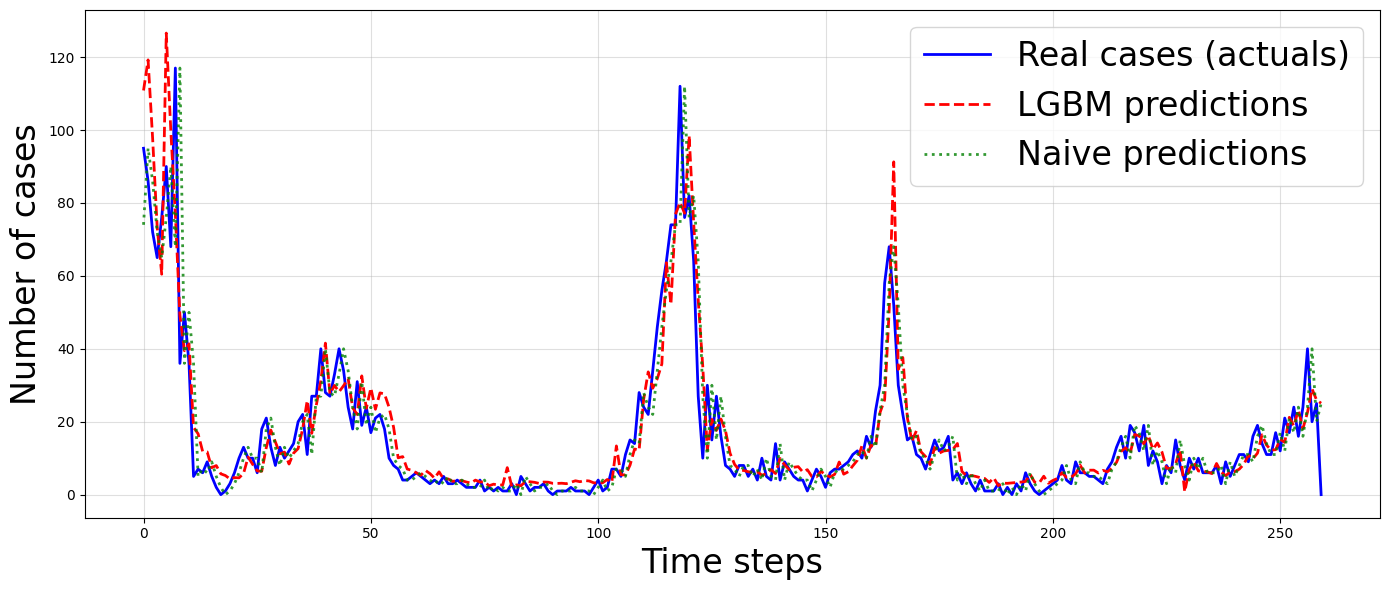

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Naive Predictions for the validation set
y_val_arr = np.asarray(y_val)
y_train_arr = np.asarray(y_train)
semana_cos = np.asarray(X_val['week_cos'])
naive_preds = np.zeros_like(y_val_arr)
# The first naive prediction uses the last known value from the training data
naive_preds[0] = y_train_arr[-1]
# The rest of the naive predictions use the previous value in the validation set
naive_preds[1:] = y_val_arr[:-1]

# 2. Create the Graphic
plt.figure(figsize=(14, 6))

# Plot Real Cases
plt.plot(y_val_arr, label='Real cases (actuals)', color='blue', linewidth=2)

# Plot LGBM Predictions
plt.plot(y_pred, label='LGBM predictions', color='red', linestyle='--', linewidth=2)

# Plot Naive Predictions
plt.plot(naive_preds, label='Naive predictions', color='green', linestyle=':', linewidth=2, alpha=0.8)

# Formatting the plot
plt.xlabel('Time steps', fontsize=24)
plt.ylabel('Number of cases', fontsize=24)
plt.legend(loc='best', fontsize=24)
plt.grid(True, alpha=0.4)
plt.tight_layout()

# Display the plot
plt.show()

DTW test

In [ ]:
pip install fastdtw scipy

In [ ]:
from fastdtw import fastdtw

# 1. Asegurarnos de que las series estén aplanadas
y_val_1d = y_val_arr.flatten()
y_pred_1d = y_pred.flatten()
naive_preds_1d = naive_preds.flatten()

# 2. Calcular DTW sin forzar scipy.spatial.distance
# Al omitir 'dist=euclidean', fastdtw maneja los escalares correctamente
distancia_lgbm, path_lgbm = fastdtw(y_val_1d, y_pred_1d, radius = 100)
distancia_naive, path_naive = fastdtw(y_val_1d, naive_preds_1d, radius = 100)

# 3. Imprimir los resultados
print("=== Resultados de Dynamic Time Warping (DTW) ===")
print(f"DTW (Casos Reales vs LGBM)  : {distancia_lgbm:.2f}")
print(f"DTW (Casos Reales vs Naive) : {distancia_naive:.2f}")

# Interpretación rápida
if distancia_lgbm < distancia_naive:
    print("\nConclusión: El modelo LGBM tiene una menor distancia DTW. Capta mejor la forma de la epidemia que el modelo Naive, mitigando en parte la crítica del desfase.")
else:
    print("\nConclusión: El modelo LGBM tiene un DTW similar o peor que el Naive. Esto confirma matemáticamente la observación visual del revisor sobre el rezago.")

ModuleNotFoundError: No module named 'fastdtw'

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_test = pd.read_csv('X_val_Iquitos.csv')
naive_preds = df_test['cases_lag1'].values

# 1. Asegurar que todo sea 1D
y_val_1d = np.asarray(y_val).flatten()
y_pred_1d = np.asarray(y_pred).flatten()
naive_preds_1d = np.asarray(naive_preds).flatten()

# 2. Definir el umbral (Percentil 90)
umbral = np.percentile(y_val_1d, 99)
picos_mask = y_val_1d > umbral
valles_mask = y_val_1d <= umbral

# 3. Función auxiliar para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# 4. Calcular para PICOS
mae_lgbm_p, rmse_lgbm_p = calcular_metricas(y_val_1d[picos_mask], y_pred_1d[picos_mask])
mae_naive_p, rmse_naive_p = calcular_metricas(y_val_1d[picos_mask], naive_preds_1d[picos_mask])

mejora_mae_p = ((mae_naive_p - mae_lgbm_p) / mae_naive_p) * 100
mejora_rmse_p = ((rmse_naive_p - rmse_lgbm_p) / rmse_naive_p) * 100

# 5. Calcular para VALLES
mae_lgbm_v, rmse_lgbm_v = calcular_metricas(y_val_1d[valles_mask], y_pred_1d[valles_mask])
mae_naive_v, rmse_naive_v = calcular_metricas(y_val_1d[valles_mask], naive_preds_1d[valles_mask])

mejora_mae_v = ((mae_naive_v - mae_lgbm_v) / mae_naive_v) * 100
mejora_rmse_v = ((rmse_naive_v - rmse_lgbm_v) / rmse_naive_v) * 100

# 6. Imprimir Resultados Formateados
print(f"=== ANÁLISIS ESTRATIFICADO (Umbral: P90 = {umbral:.1f} casos) ===\n")

print("🔴 EN LOS PICOS (10% de las semanas más críticas):")
print(f"MAE  -> LGBM: {mae_lgbm_p:.2f} | Naive: {mae_naive_p:.2f} | Mejora: {mejora_mae_p:.1f}%")
print(f"RMSE -> LGBM: {rmse_lgbm_p:.2f} | Naive: {rmse_naive_p:.2f} | Mejora: {mejora_rmse_p:.1f}%\n")

print("🟢 EN LOS VALLES (90% de las semanas endémicas):")
print(f"MAE  -> LGBM: {mae_lgbm_v:.2f} | Naive: {mae_naive_v:.2f} | Mejora: {mejora_mae_v:.1f}%")
print(f"RMSE -> LGBM: {rmse_lgbm_v:.2f} | Naive: {rmse_naive_v:.2f} | Mejora: {mejora_rmse_v:.1f}%\n")

print("=== RESUMEN PARA EL PAPER ===")
if mejora_mae_p > 0 and mejora_rmse_p > 0:
    print("ÉXITO: El modelo supera a la persistencia en los picos epidémicos.")
else:
    print("ATENCIÓN: Revisa los valores, el Naive es superior en alguna métrica del pico.")

=== ANÁLISIS ESTRATIFICADO (Umbral: P90 = 92.1 casos) ===

🔴 EN LOS PICOS (10% de las semanas más críticas):
MAE  -> LGBM: 29.29 | Naive: 36.00 | Mejora: 18.6%
RMSE -> LGBM: 30.98 | Naive: 37.80 | Mejora: 18.0%

🟢 EN LOS VALLES (90% de las semanas endémicas):
MAE  -> LGBM: 5.16 | Naive: 5.22 | Mejora: 1.1%
RMSE -> LGBM: 8.21 | Naive: 9.13 | Mejora: 10.1%

=== RESUMEN PARA EL PAPER ===
ÉXITO: El modelo supera a la persistencia en los picos epidémicos.


=== Análisis de Percentiles (Casos Reales) ===
Mediana (50%) : 8.0 casos
Percentil 75  : 17.0 casos
Percentil 85  : 21.0 casos
Percentil 90  : 34.2 casos
Percentil 95  : 92.1 casos



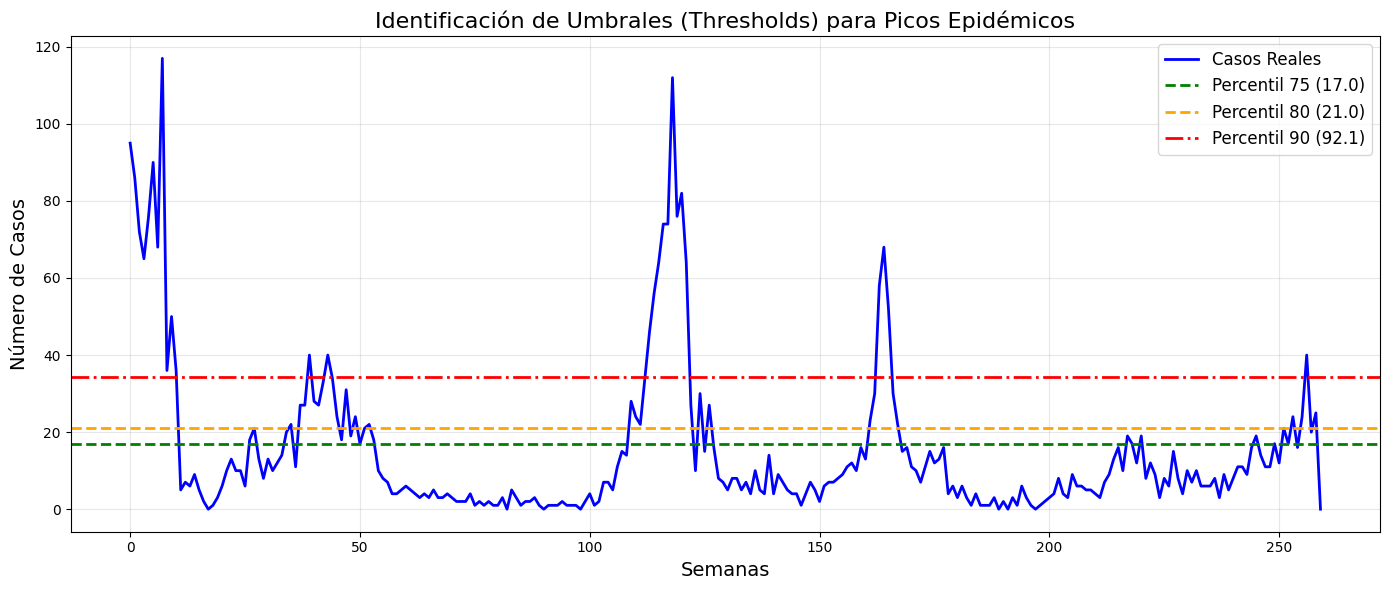

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Asegurar que los datos reales estén aplanados a 1D
y_real = np.asarray(y_val).flatten()

# 2. Calcular los percentiles clave
p50 = np.percentile(y_real, 50) # Mediana (la mitad de las semanas tienen menos casos que esto)
p75 = np.percentile(y_real, 75) # Umbral clásico para "inicio de epidemia"
p80 = np.percentile(y_real, 80) # Umbral para brotes moderados
p90 = np.percentile(y_real, 90) # Umbral para picos altos
p95 = np.percentile(y_real, 99) # Umbral para picos extremos

# 3. Imprimir los resultados en consola
print("=== Análisis de Percentiles (Casos Reales) ===")
print(f"Mediana (50%) : {p50:.1f} casos")
print(f"Percentil 75  : {p75:.1f} casos")
print(f"Percentil 85  : {p80:.1f} casos")
print(f"Percentil 90  : {p90:.1f} casos")
print(f"Percentil 95  : {p95:.1f} casos\n")

# 4. Graficar la serie de tiempo con las líneas de los percentiles
plt.figure(figsize=(14, 6))
plt.plot(y_real, label='Casos Reales', color='blue', linewidth=2)

# Añadir líneas horizontales para los percentiles más útiles
plt.axhline(p75, color='green', linestyle='--', linewidth=2, label=f'Percentil 75 ({p75:.1f})')
plt.axhline(p80, color='orange', linestyle='--', linewidth=2, label=f'Percentil 80 ({p80:.1f})')
plt.axhline(p90, color='red', linestyle='-.', linewidth=2, label=f'Percentil 90 ({p95:.1f})')

# Formato del gráfico
plt.title('Identificación de Umbrales (Thresholds) para Picos Epidémicos', fontsize=16)
plt.xlabel('Semanas', fontsize=14)
plt.ylabel('Número de Casos', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

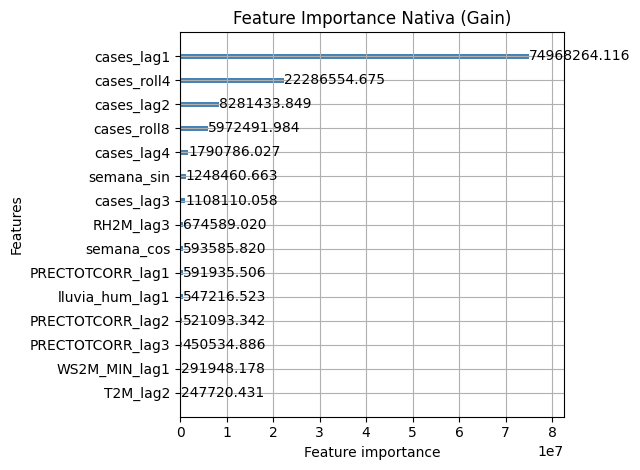

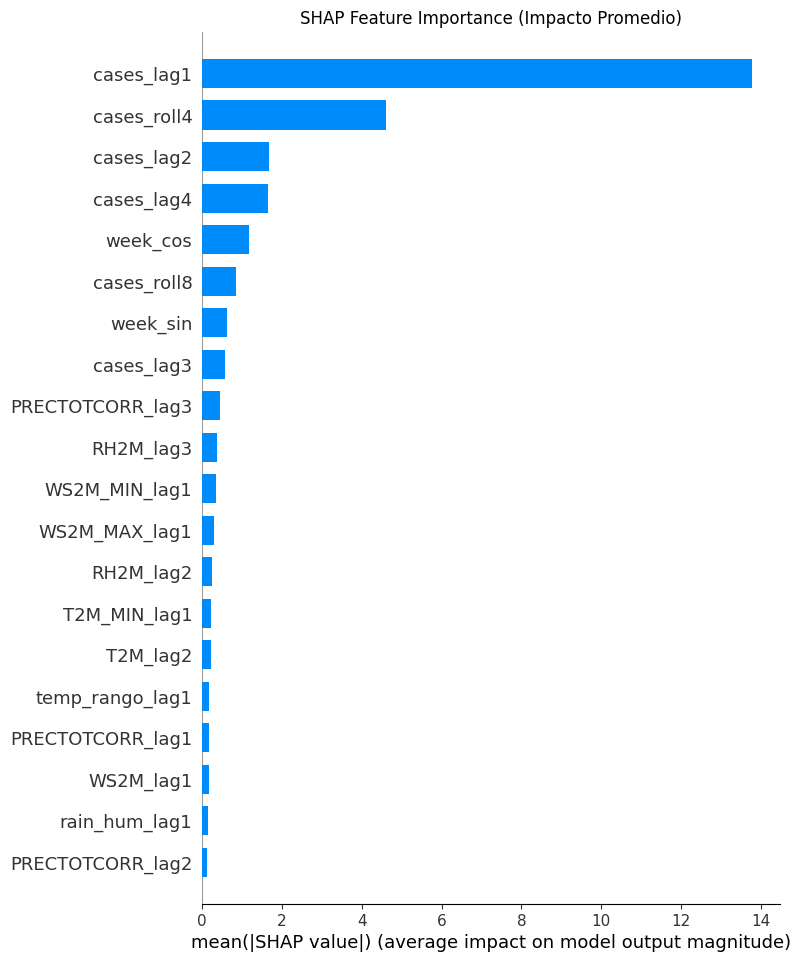

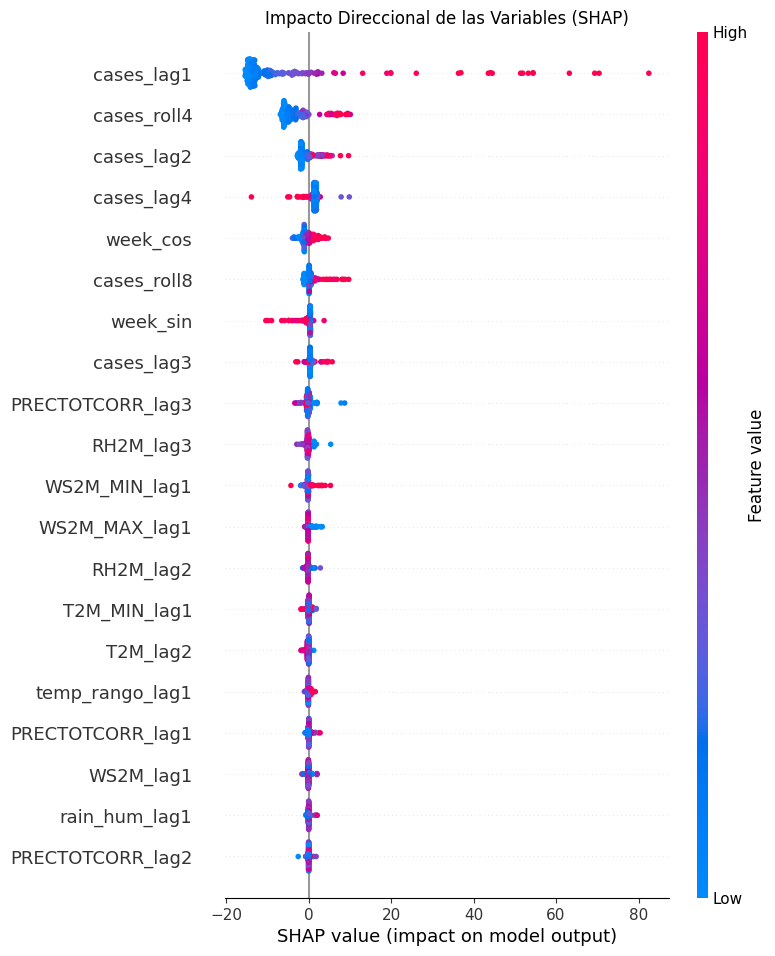

In [ ]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap

# ==========================================
# MÉTODO 1: Importancia Nativa de LightGBM
# ==========================================
# importance_type puede ser 'split' (cuántas veces se usó la variable para dividir los datos)
# o 'gain' (cuánta mejora en el error trajo esa variable). 'gain' suele ser más representativo.

plt.figure(figsize=(10, 6))
lgb.plot_importance(model,
                    importance_type='gain',
                    max_num_features=15,
                    title='Feature Importance Nativa (Gain)',
                    color='steelblue')
plt.tight_layout()
plt.show()

# ==========================================
# MÉTODO 2: Importancia mediante SHAP (XAI)
# ==========================================
# Esto calcula la contribución marginal de cada variable

# 1. Crear el explainer usando tu modelo entrenado
explainer = shap.TreeExplainer(model)

# 2. Calcular los valores SHAP sobre tu conjunto de validación o test (X_val)
shap_values = explainer.shap_values(X_val)

# 3. Gráfico de barras general (Promedio del impacto absoluto)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Impacto Promedio)')
plt.show()

# 4. Gráfico de abejas (Beeswarm) - El más rico en información
# Muestra no solo la importancia, sino si valores altos/bajos de la variable
# aumentan o disminuyen los casos de dengue.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, show=False)
plt.title('Impacto Direccional de las Variables (SHAP)')
plt.show()

In [ ]:
import numpy as np

# Aplanar los arrays
y_val_1d = np.asarray(y_val).flatten()
y_pred_1d = np.asarray(y_pred).flatten()

# Encontrar el índice (paso de tiempo) donde ocurre el pico máximo
pico_real_idx = np.argmax(y_val_1d)
pico_pred_idx = np.argmax(y_pred_1d)

# Calcular el desfase
desfase = pico_pred_idx - pico_real_idx

print(f"Paso de tiempo del pico REAL: {pico_real_idx}")
print(f"Paso de tiempo del pico PREDICHO: {pico_pred_idx}")
print(f"Desfase (Time-to-Peak Error): {desfase} pasos de tiempo")

Paso de tiempo del pico REAL: 7
Paso de tiempo del pico PREDICHO: 5
Desfase (Time-to-Peak Error): -2 pasos de tiempo


In [ ]:
y_pred_arr = np.asarray(y_pred).ravel()
y_val_arr = np.asarray(y_val).ravel()

df_preds = pd.DataFrame({
    'y_pred': y_pred_arr,
    'y_val': y_val_arr
})

df_preds.iloc[150:180]

,y_pred,y_val
150,5.452599,2
151,4.853051,6
152,5.554980,7
153,8.949575,7
154,5.616365,8
155,6.280347,9
156,7.900344,11
157,9.434411,12
158,13.403520,10
159,10.030237,16


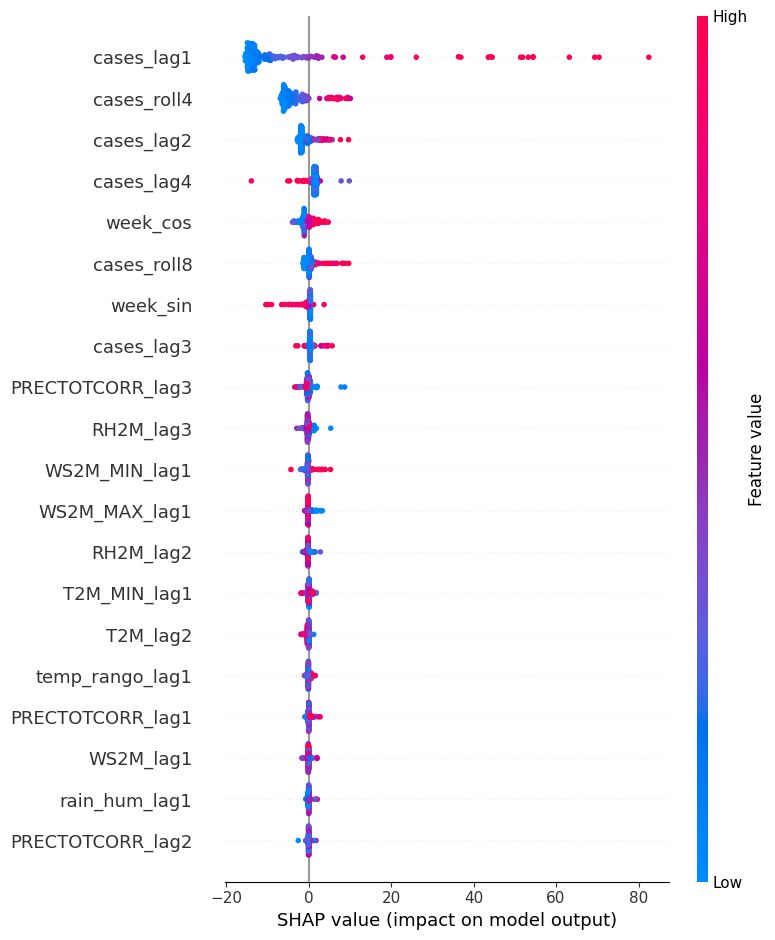

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(model)

shap_values = explainer(X_val)

shap.summary_plot(shap_values, X_val)

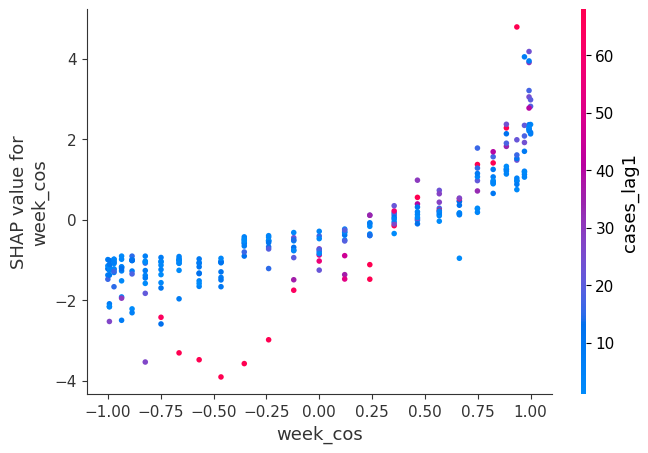

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

shap.dependence_plot(
    'week_cos',
    shap_values.values,
    X_val,
    interaction_index='cases_lag1'
)

In [ ]:
X_train.columns

Index(['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4', 'cases_roll4',
       'cases_roll8', 'T2M_lag1', 'T2M_MAX_lag1', 'T2M_MIN_lag1',
       'PRECTOTCORR_lag1', 'RH2M_lag1', 'WS2M_lag1', 'WS2M_MAX_lag1',
       'WS2M_MIN_lag1', 'PRECTOTCORR_lag2', 'RH2M_lag2', 'T2M_lag2',
       'PRECTOTCORR_lag3', 'RH2M_lag3', 'semana_sin', 'semana_cos',
       'temp_rango_lag1', 'lluvia_hum_lag1'],
      dtype='object')

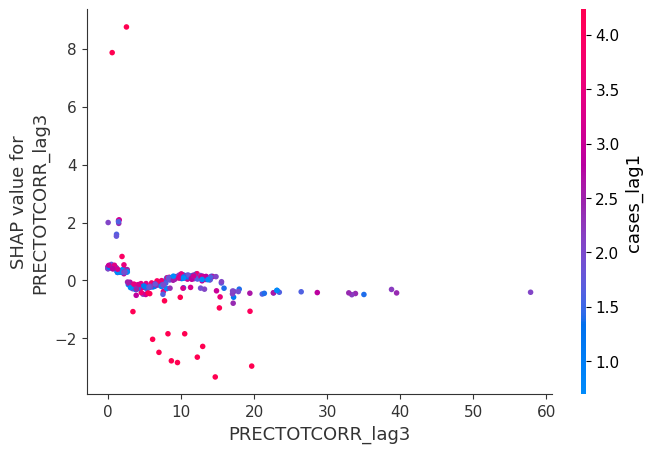

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'PRECTOTCORR_lag3',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

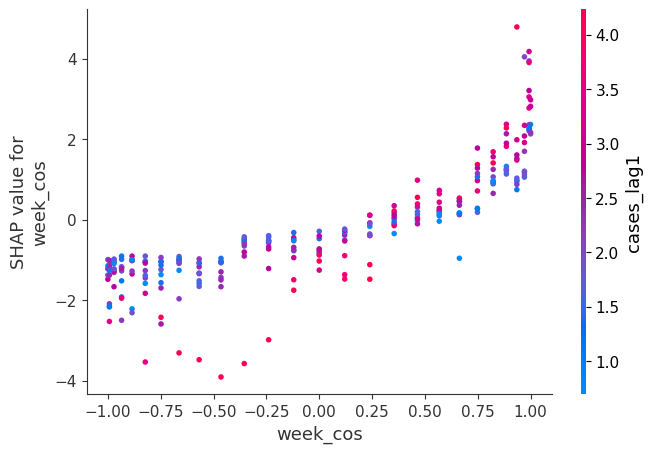

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'week_cos',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

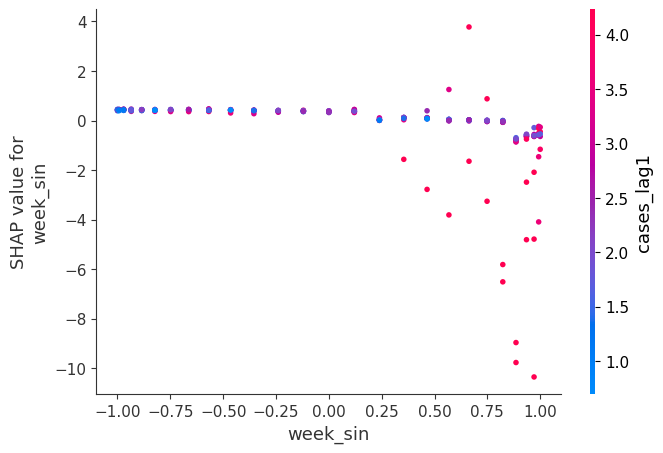

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'week_sin',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

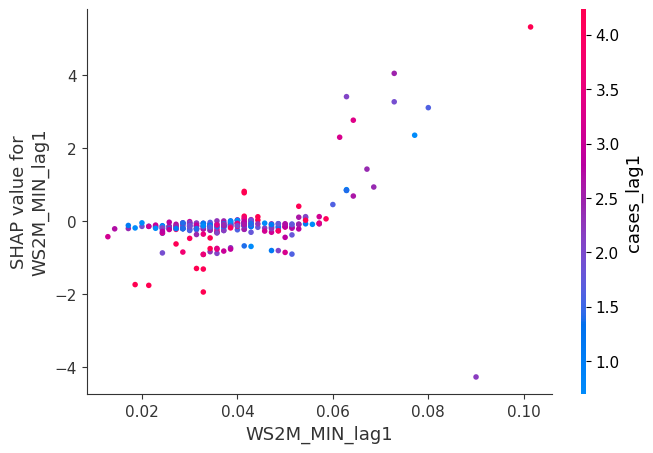

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'WS2M_MIN_lag1',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

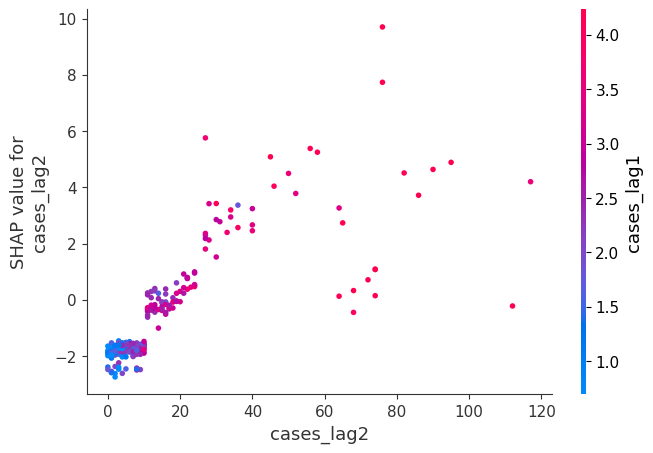

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'cases_lag2',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

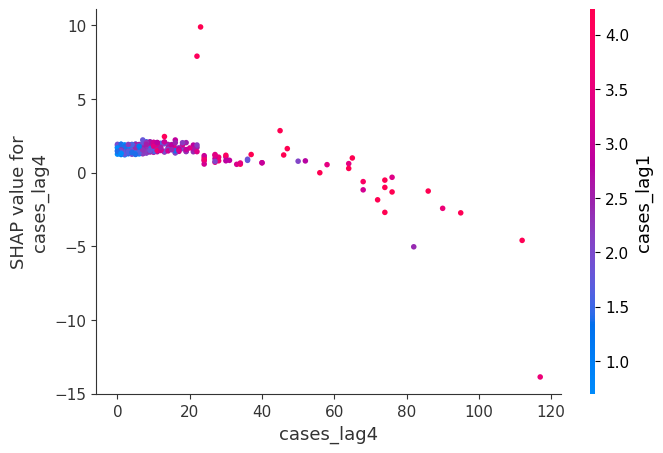

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])


shap.dependence_plot(
    'cases_lag4',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

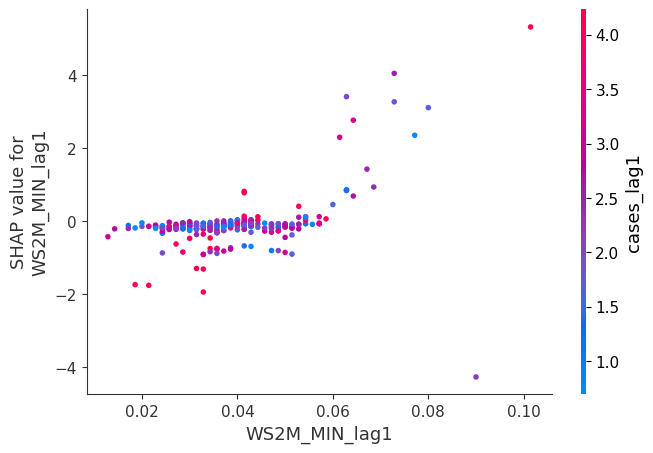

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()
X_val_plot['cases_lag1'] = np.log1p(X_val_plot['cases_lag1'])

shap.dependence_plot(
    'WS2M_MIN_lag1',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

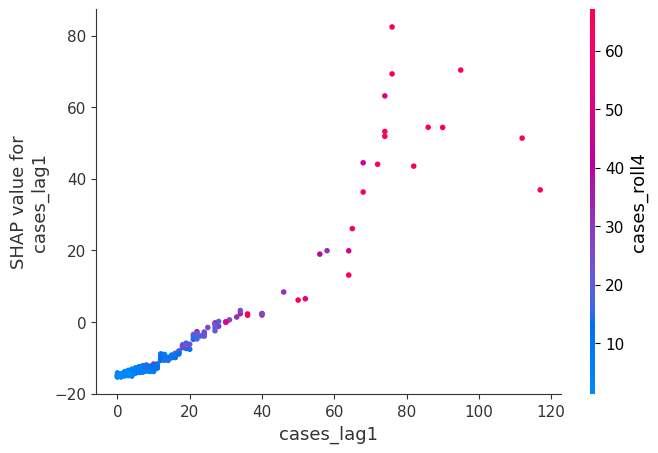

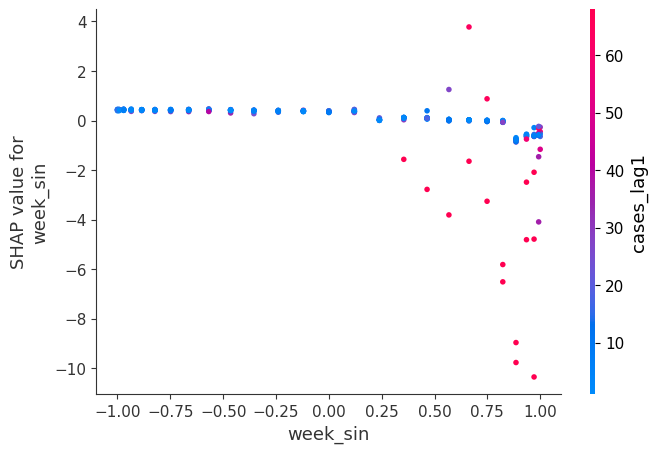

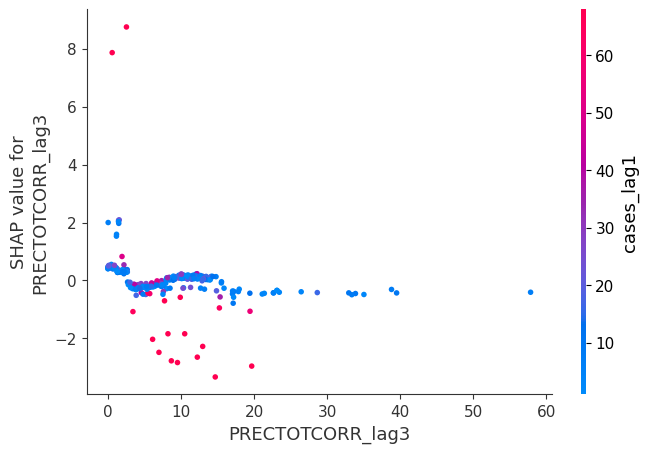

In [ ]:
import shap
import matplotlib.pyplot as plt

# Ensure your explainer and shap_values are already calculated:
# explainer = shap.Explainer(model)
# shap_values = explainer(X_val)

# 1. Immediate Past vs. Recent Trend
shap.dependence_plot(
    'cases_lag1',
    shap_values.values,
    X_val,
    interaction_index='cases_roll4'
)

# 2. Seasonality (Sine component) vs. Immediate Past
shap.dependence_plot(
    'week_sin',
    shap_values.values,
    X_val,
    interaction_index='cases_lag1'
)

# 3. Top Weather Feature vs. Immediate Past
shap.dependence_plot(
    'PRECTOTCORR_lag3',
    shap_values.values,
    X_val,
    interaction_index='cases_lag1'
)

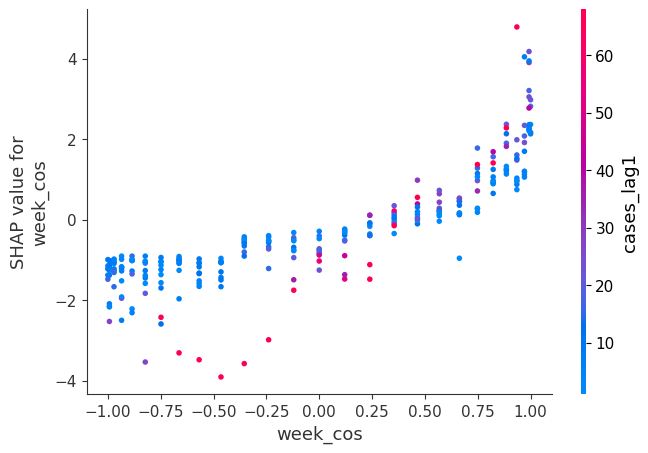

In [ ]:
shap.dependence_plot(
    'week_cos',
    shap_values.values,
    X_val,
    interaction_index='cases_lag1'
)

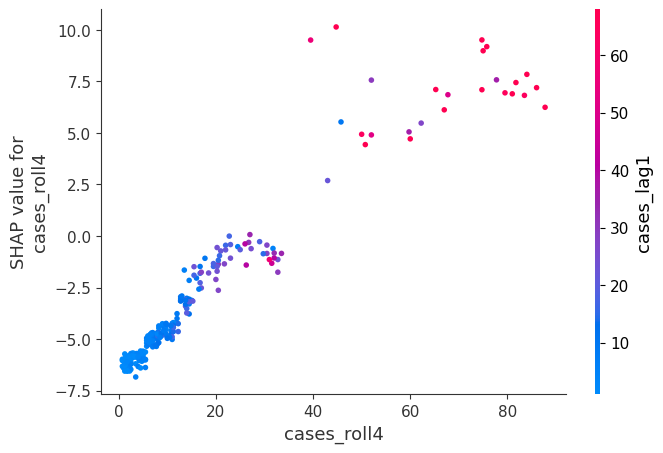

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()

shap.dependence_plot(
    'cases_roll4',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_lag1'
)

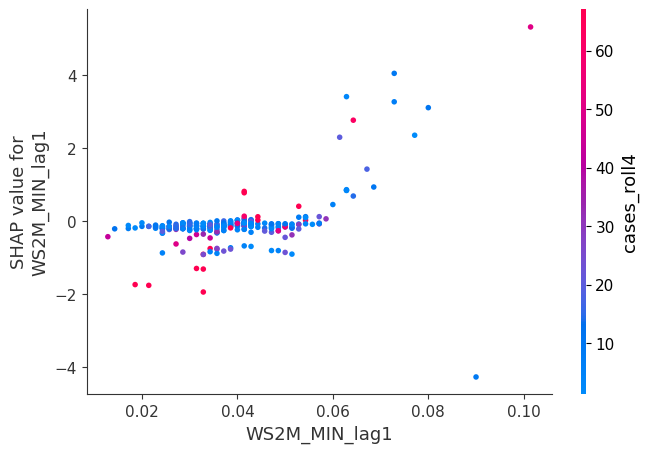

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()

shap.dependence_plot(
    'WS2M_MIN_lag1',
    shap_values.values,
    X_val_plot,
    interaction_index='cases_roll4'
)

In [ ]:
X_train.columns

Index(['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4', 'cases_roll4',
       'cases_roll8', 'T2M_lag1', 'T2M_MAX_lag1', 'T2M_MIN_lag1',
       'PRECTOTCORR_lag1', 'RH2M_lag1', 'WS2M_lag1', 'WS2M_MAX_lag1',
       'WS2M_MIN_lag1', 'PRECTOTCORR_lag2', 'RH2M_lag2', 'T2M_lag2',
       'PRECTOTCORR_lag3', 'RH2M_lag3', 'semana_sin', 'semana_cos',
       'temp_rango_lag1', 'lluvia_hum_lag1'],
      dtype='object')

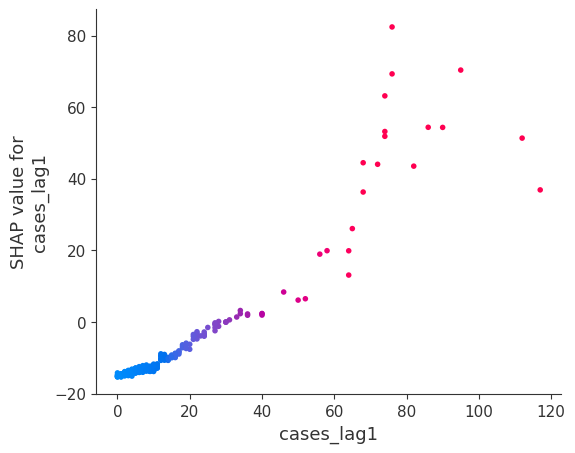

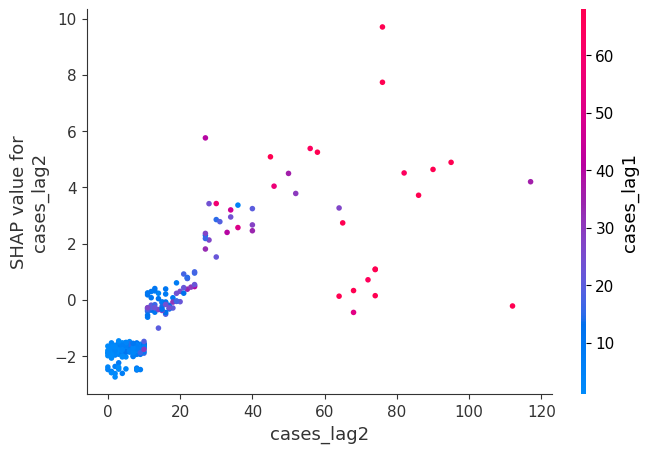

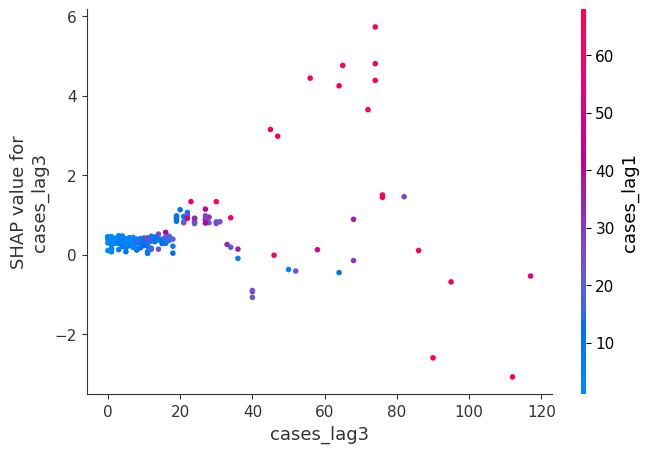

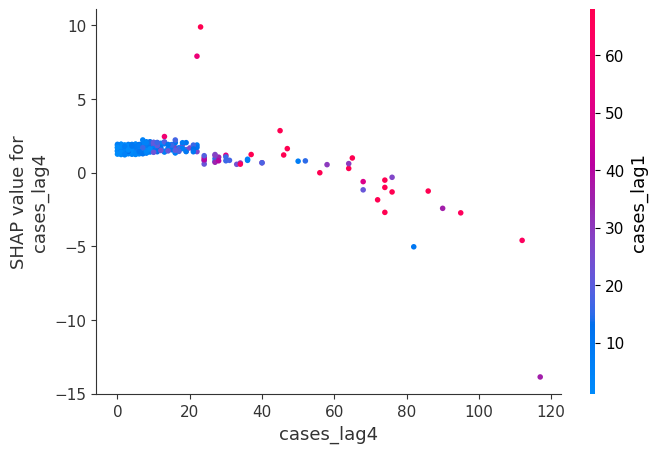

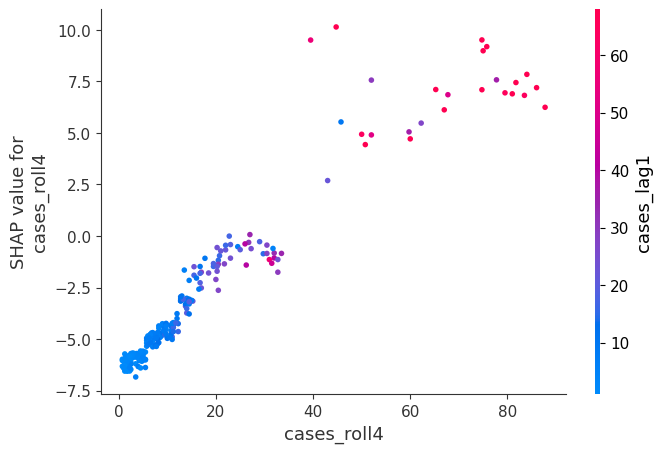

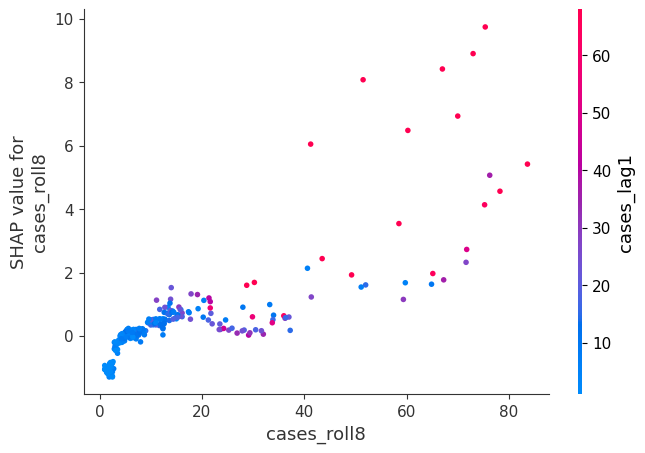

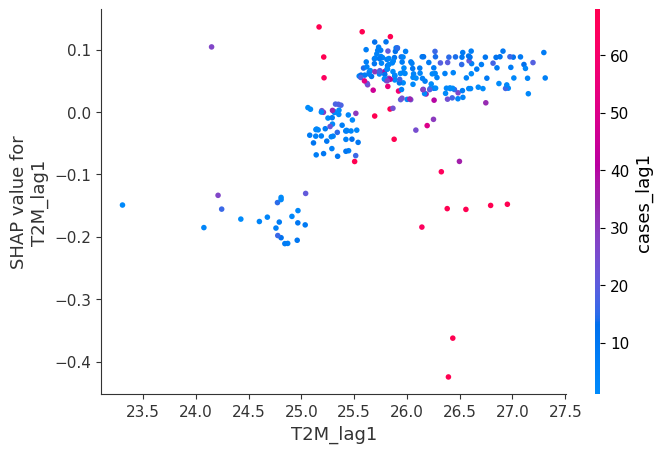

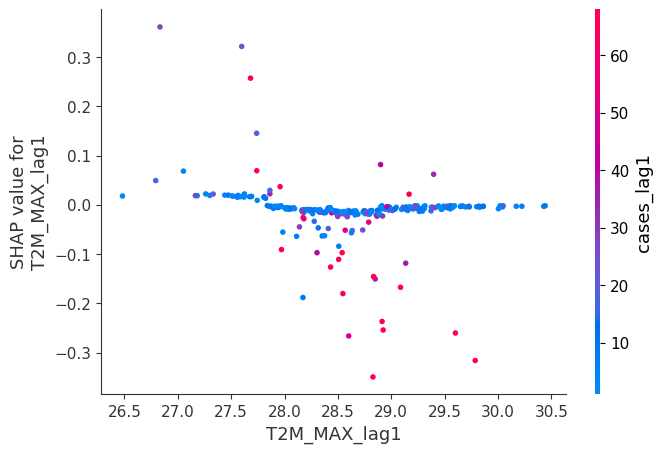

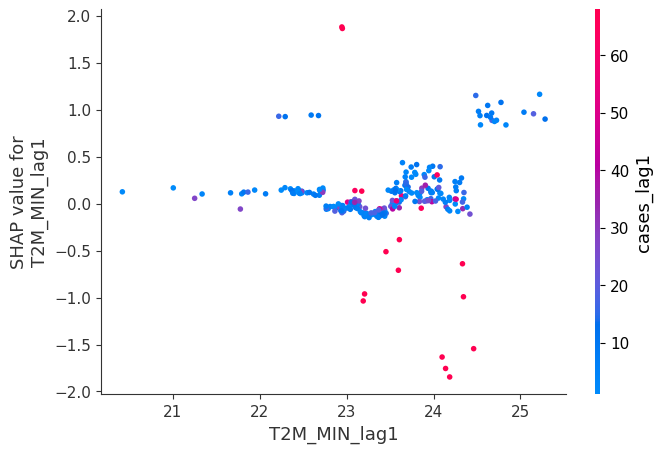

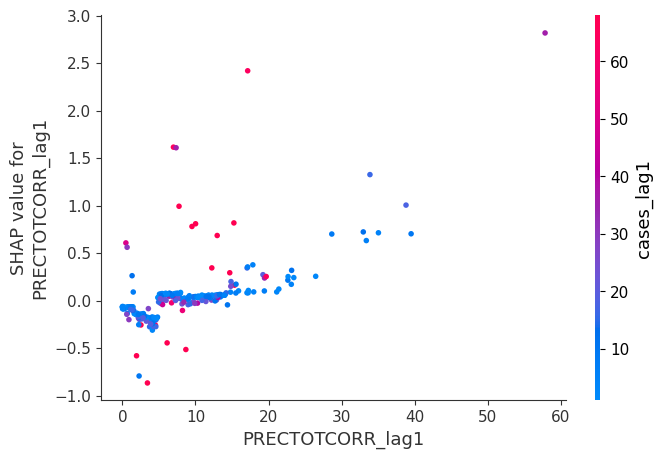

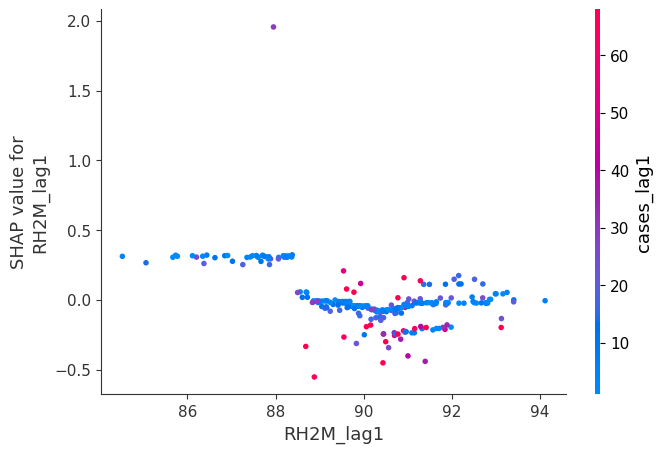

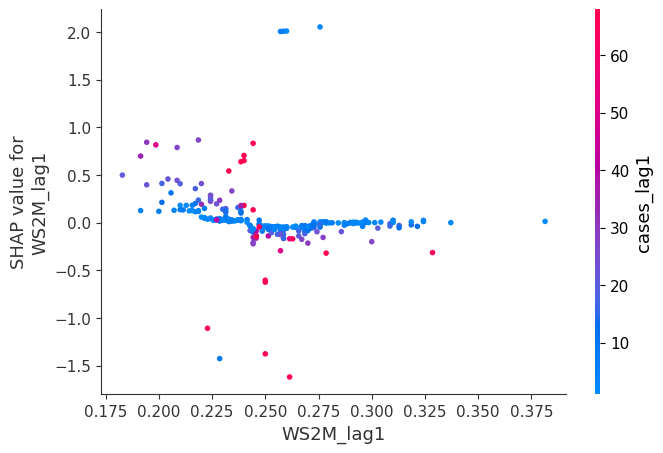

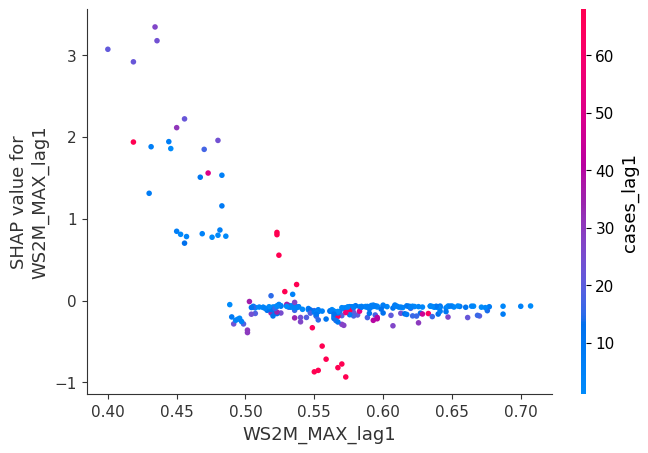

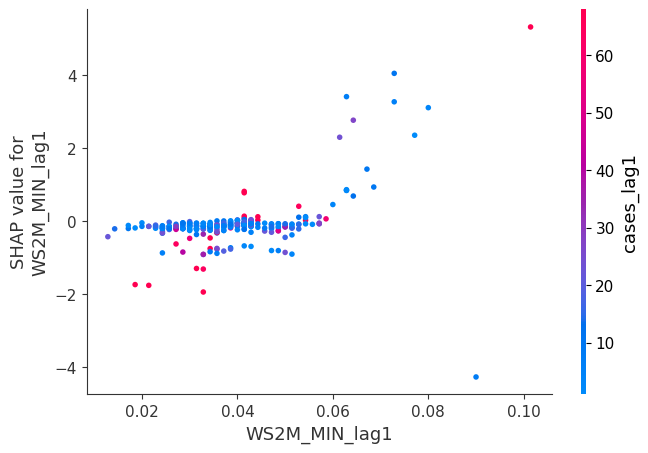

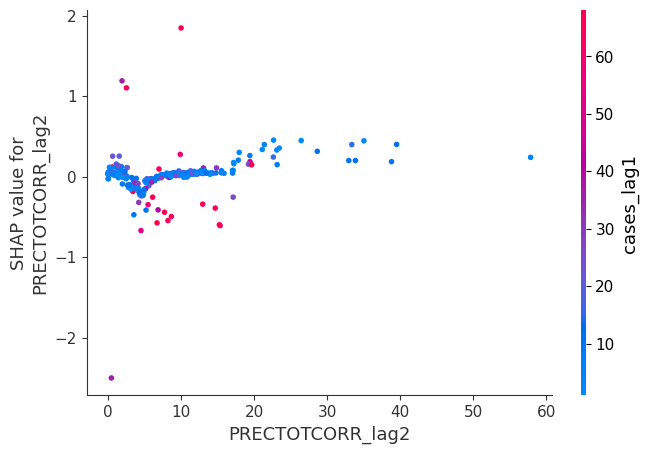

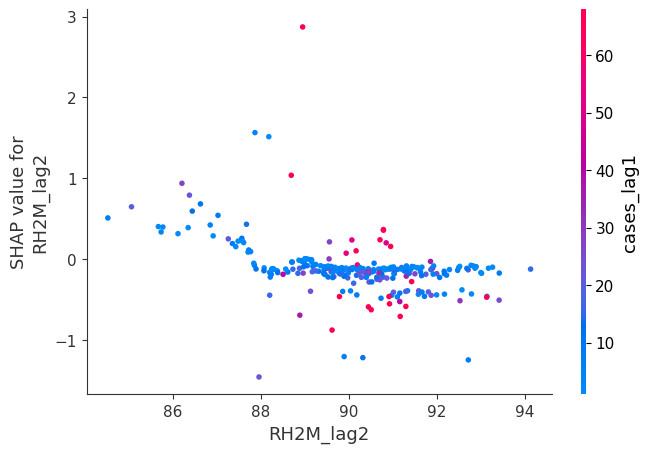

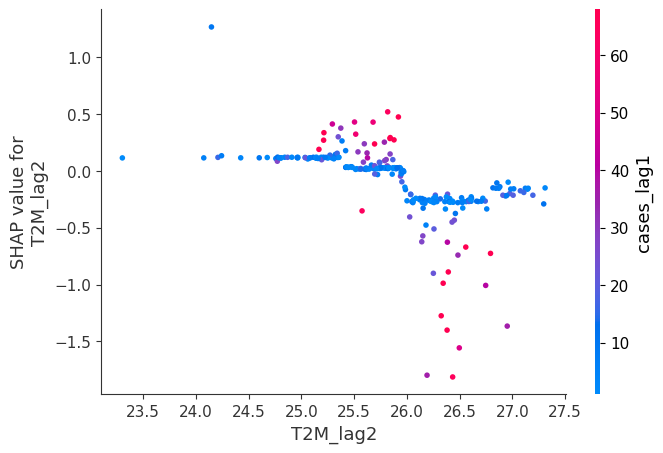

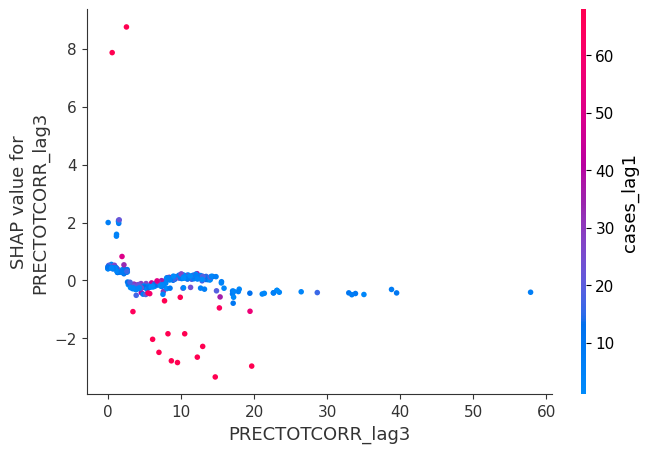

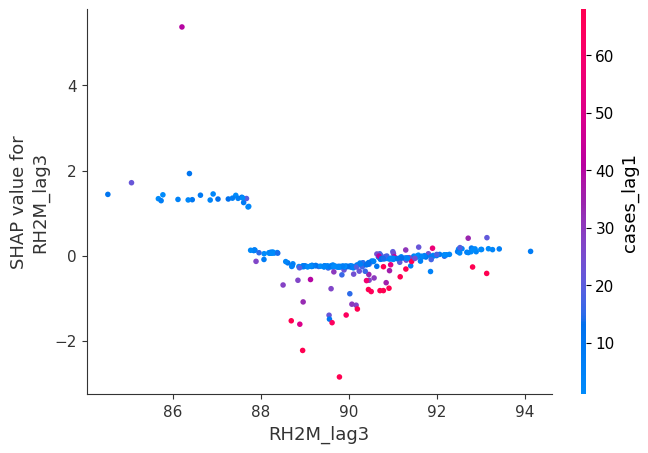

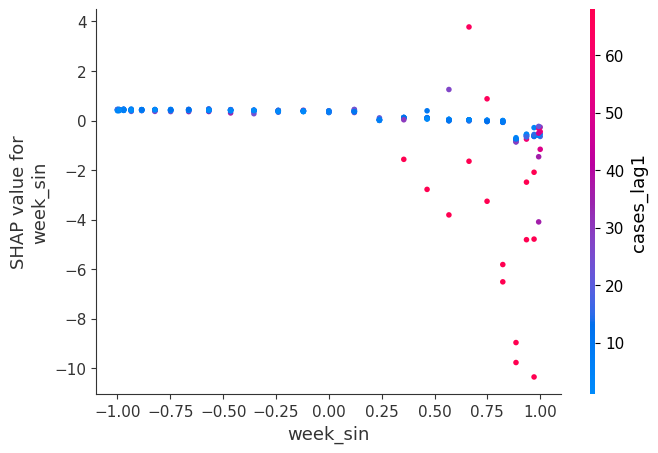

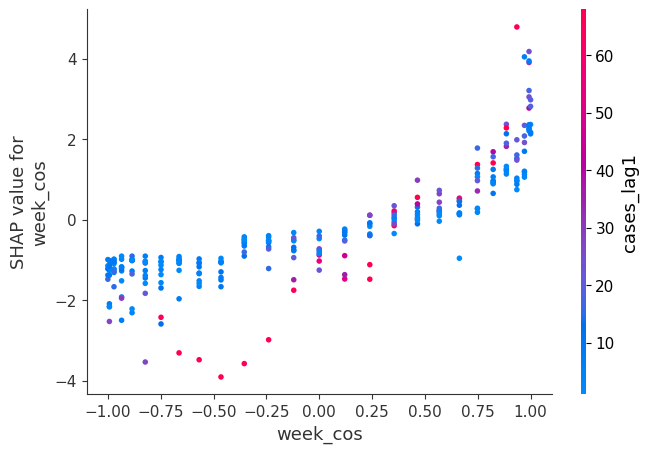

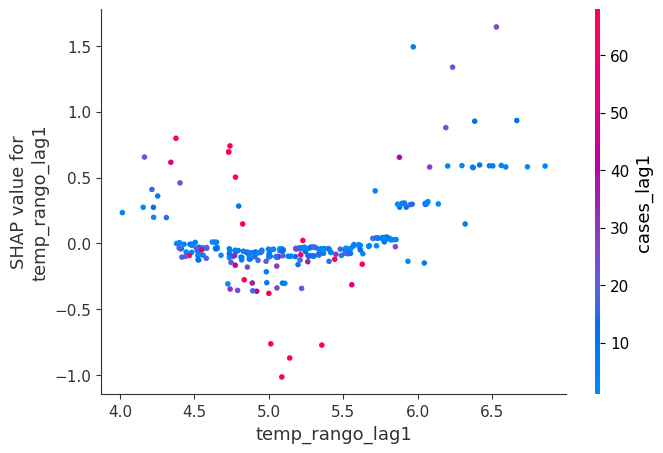

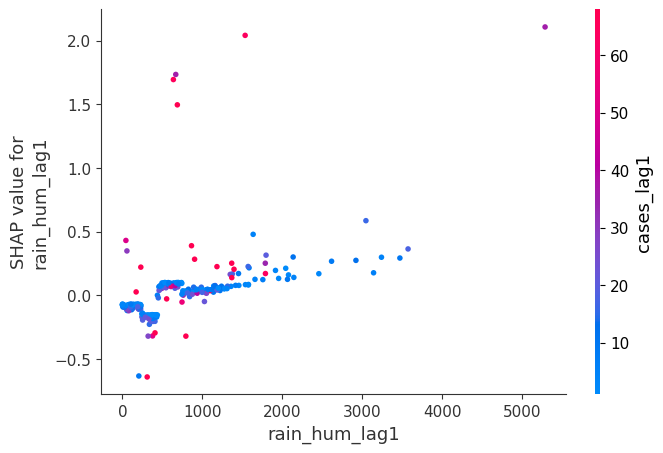

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

X_val_plot = X_val.copy()


for var in X_val_plot.columns:
  shap.dependence_plot(
      var,
      shap_values.values,
      X_val_plot,
      interaction_index='cases_lag1'
  )

In [ ]:
X_train.columns

Index(['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4', 'cases_roll4',
       'cases_roll8', 'T2M_lag1', 'T2M_MAX_lag1', 'T2M_MIN_lag1',
       'PRECTOTCORR_lag1', 'RH2M_lag1', 'WS2M_lag1', 'WS2M_MAX_lag1',
       'WS2M_MIN_lag1', 'PRECTOTCORR_lag2', 'RH2M_lag2', 'T2M_lag2',
       'PRECTOTCORR_lag3', 'RH2M_lag3', 'semana_sin', 'semana_cos',
       'temp_rango_lag1', 'lluvia_hum_lag1'],
      dtype='object')



########## HORIZONTE 2 SEMANAS ##########
Train: (1036, 23)
Val  : (258, 23)

LightGBM (2 semanas)
MAE  : 10.616
nMAE : 0.733
RMSE : 14.713
R²   : 0.398


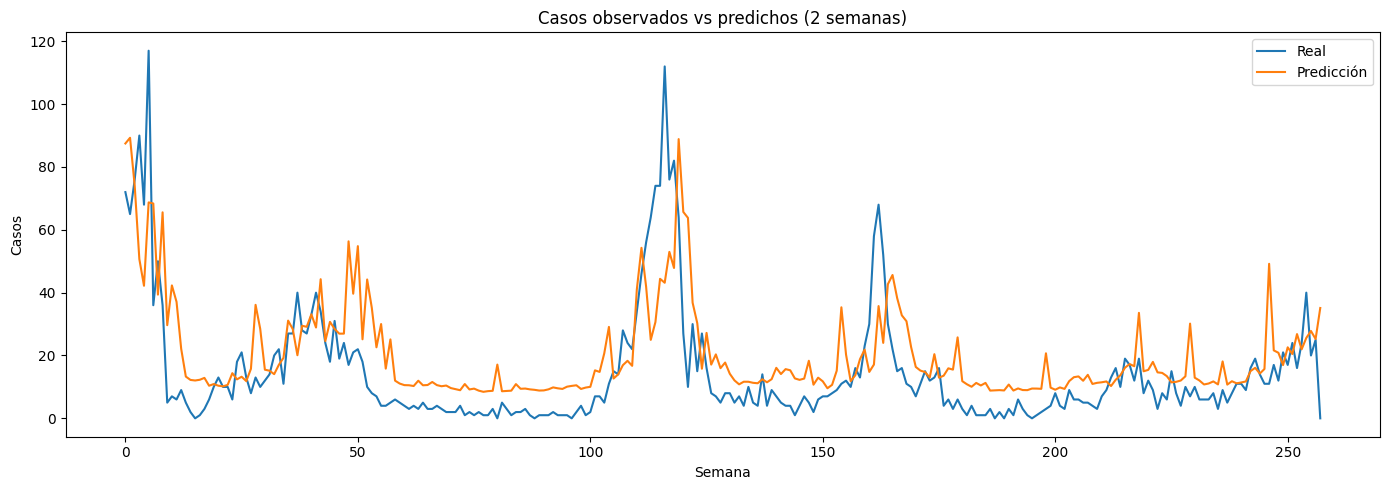

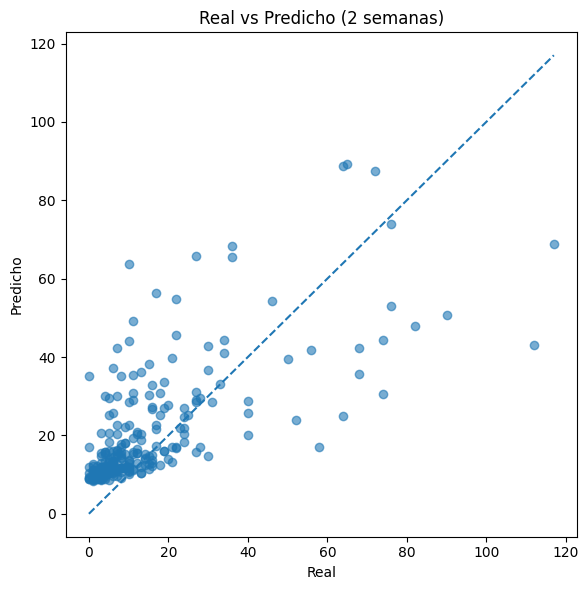

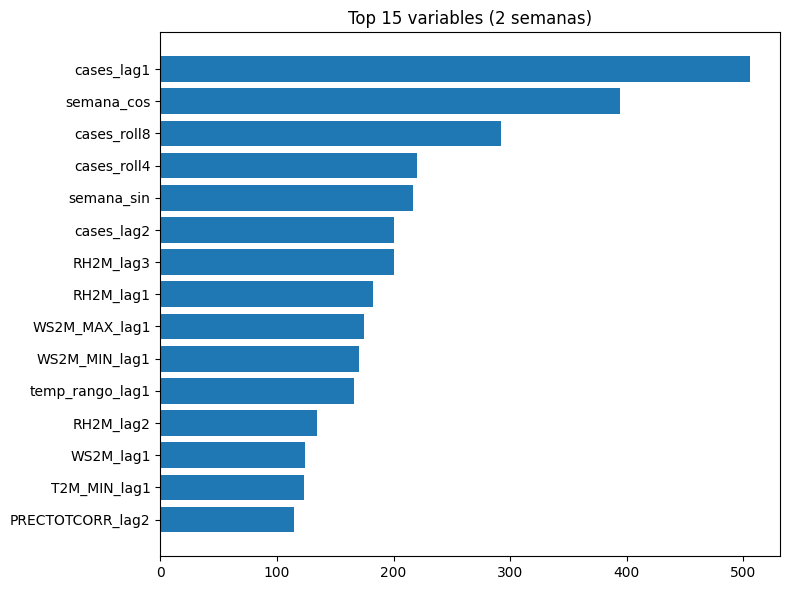


Top 15 variables:
             feature  importance
0         cases_lag1         506
20        semana_cos         394
5        cases_roll8         292
4        cases_roll4         220
19        semana_sin         217
1         cases_lag2         200
18         RH2M_lag3         200
10         RH2M_lag1         182
12     WS2M_MAX_lag1         175
13     WS2M_MIN_lag1         170
21   temp_rango_lag1         166
15         RH2M_lag2         134
11         WS2M_lag1         124
8       T2M_MIN_lag1         123
14  PRECTOTCORR_lag2         115


########## HORIZONTE 3 SEMANAS ##########
Train: (1035, 23)
Val  : (257, 23)

LightGBM (3 semanas)
MAE  : 12.459
nMAE : 0.873
RMSE : 16.781
R²   : 0.191


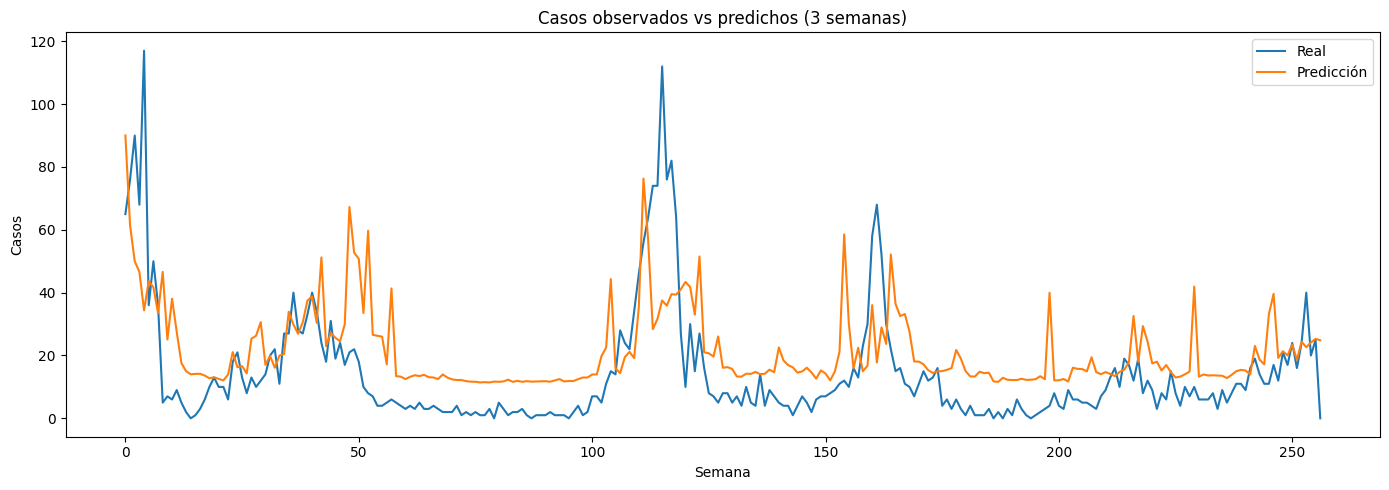

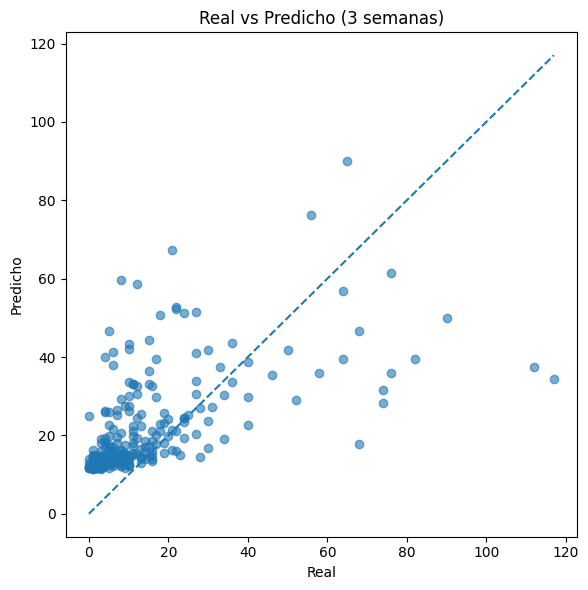

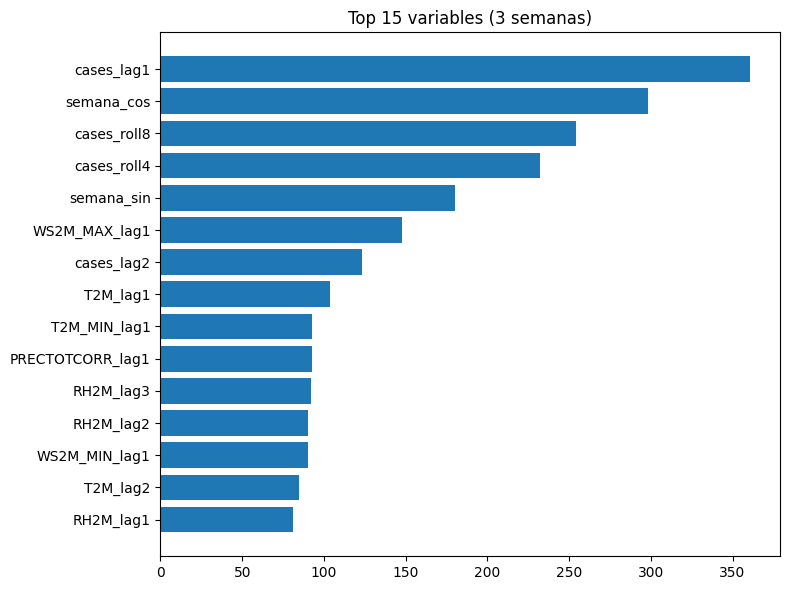


Top 15 variables:
             feature  importance
0         cases_lag1         361
20        semana_cos         298
5        cases_roll8         254
4        cases_roll4         232
19        semana_sin         180
12     WS2M_MAX_lag1         148
1         cases_lag2         123
6           T2M_lag1         104
8       T2M_MIN_lag1          93
9   PRECTOTCORR_lag1          93
18         RH2M_lag3          92
15         RH2M_lag2          90
13     WS2M_MIN_lag1          90
16          T2M_lag2          85
10         RH2M_lag1          81


In [ ]:
# ============================================================
# PREDICCIÓN DE CASOS DE DENGUE A 4 Y 8 SEMANAS CON LIGHTGBM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor, early_stopping, log_evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# CARGA DE DATOS
# ============================================================

X_train = pd.read_csv("X_train_Iquitos.csv")
y_train = pd.read_csv("y_train_Iquitos.csv").squeeze()

X_val = pd.read_csv("X_val_Iquitos.csv")
y_val = pd.read_csv("y_val_Iquitos.csv").squeeze()

# ============================================================
# FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Normalized MAE
    nmae = mae / np.mean(y_true)

    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")
    print(f"MAE  : {mae:.3f}")
    print(f"nMAE : {nmae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

    return {
        "MAE": mae,
        "nMAE": nmae,
        "RMSE": rmse,
        "R2": r2
    }


# ============================================================
# FUNCIÓN PARA ENTRENAR Y EVALUAR UN HORIZONTE
# ============================================================

def train_horizon(
    horizon,
    X_train,
    y_train,
    X_val,
    y_val
):

    print(f"\n\n########## HORIZONTE {horizon} SEMANAS ##########")

    # --------------------------------------------------------
    # Crear target desplazado
    # --------------------------------------------------------

    y_train_h = y_train.shift(-horizon)
    y_val_h = y_val.shift(-horizon)

    train_mask = y_train_h.notna()
    val_mask = y_val_h.notna()

    X_train_h = X_train.loc[train_mask].reset_index(drop=True)
    y_train_h = y_train_h.loc[train_mask].reset_index(drop=True)

    X_val_h = X_val.loc[val_mask].reset_index(drop=True)
    y_val_h = y_val_h.loc[val_mask].reset_index(drop=True)

    print("Train:", X_train_h.shape)
    print("Val  :", X_val_h.shape)

    # --------------------------------------------------------
    # Modelo LightGBM
    # --------------------------------------------------------

    model = LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train_h,
        y_train_h,
        eval_set=[(X_val_h, y_val_h)],
        eval_metric="l1",
        callbacks=[
            early_stopping(100, verbose=False),
            log_evaluation(0)
        ]
    )

    # --------------------------------------------------------
    # Predicciones
    # --------------------------------------------------------

    pred = model.predict(X_val_h)

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    evaluate_model(
        f"LightGBM ({horizon} semanas)",
        y_val_h,
        pred
    )

    # --------------------------------------------------------
    # Serie temporal
    # --------------------------------------------------------

    plt.figure(figsize=(14, 5))

    plt.plot(
        y_val_h.values,
        label="Real"
    )

    plt.plot(
        pred,
        label="Predicción"
    )

    plt.title(
        f"Casos observados vs predichos ({horizon} semanas)"
    )

    plt.xlabel("Semana")
    plt.ylabel("Casos")

    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Scatter Real vs Predicho
    # --------------------------------------------------------

    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_val_h,
        pred,
        alpha=0.6
    )

    max_val = max(
        np.max(y_val_h),
        np.max(pred)
    )

    plt.plot(
        [0, max_val],
        [0, max_val],
        "--"
    )

    plt.xlabel("Real")
    plt.ylabel("Predicho")

    plt.title(
        f"Real vs Predicho ({horizon} semanas)"
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Importancia de variables
    # --------------------------------------------------------

    importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "importance",
        ascending=False
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        importance.head(15)["feature"][::-1],
        importance.head(15)["importance"][::-1]
    )

    plt.title(
        f"Top 15 variables ({horizon} semanas)"
    )

    plt.tight_layout()
    plt.show()

    print("\nTop 15 variables:")
    print(importance.head(15))

    return model, importance


# ============================================================
# MODELO PARA 4 SEMANAS
# ============================================================

model_4, importance_4 = train_horizon(
    horizon=2,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

# ============================================================
# MODELO PARA 8 SEMANAS
# ============================================================

model_8, importance_8 = train_horizon(
    horizon=3,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)